# Telco Customer Churn Analysis

**Dataset:** Telco Customer Churn

**Objective:** Build ML models to predict customer churn and extract actionable business insights.

## Import Libraries

In [1]:
# Data manipulation
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# Display settings
pd.set_option('display.max_columns', 30)
sns.set_theme(style='whitegrid')

## Load the Dataset

In [2]:
# Load and keep only the standard 21 IBM Telco columns
# (avoids data leakage from extra enriched columns )
df_raw = pd.read_csv('Telco_customer_churn.csv')

standard_cols = [
    'customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
    'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'
]

df = df_raw[[c for c in standard_cols if c in df_raw.columns]].copy()

## Understand the Dataset

In [3]:
# Display first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
1,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
2,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
3,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
4,0280-XJGEX,Male,0,No,No,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes


In [4]:
# Number of rows and columns
print("Dataset Shape:", df.shape)

Dataset Shape: (7043, 21)


In [5]:
# Information about dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
# Statistical Summary
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
# Check Missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
# Duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [9]:
# Target Variable
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [10]:
churn_rate = df['Churn'].value_counts(normalize=True)['Yes'] * 100
print(f'Overall Churn Rate: {churn_rate:.2f}%')

Overall Churn Rate: 26.54%


## Data Cleaning & Preprocessing

In [11]:
# Drop customerID
df.drop(columns=['customerID'])

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
1,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
2,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
3,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
4,Male,0,No,No,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Female,0,No,No,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No
7039,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7040,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7041,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No


In [12]:
# Convert Total Charges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [13]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [14]:
# Fill missing values with median
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [15]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [16]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [17]:
# Separate Numerical and Categorical Columns
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

categorical_columns = df.select_dtypes(include=["object"]).columns

print("Numerical Columns")
print(numerical_columns)

print("\nCategorical Columns")
print(categorical_columns)

Numerical Columns
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')

Categorical Columns
Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='str')


In [18]:
# Save cleaned dataset
df.to_csv("Telco_Customer_Churn_Cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


## Exploratory Data Analysis (EDA)

1. Churn Distribution

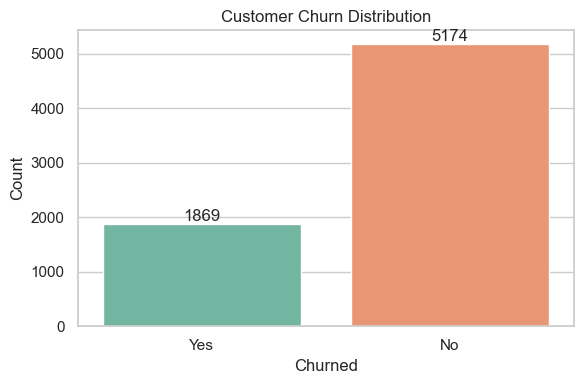

In [19]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Churn', data=df, palette='Set2')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Customer Churn Distribution')
plt.xlabel('Churned'); plt.ylabel('Count')
plt.tight_layout(); plt.show()

2. Contract Type vs Churn

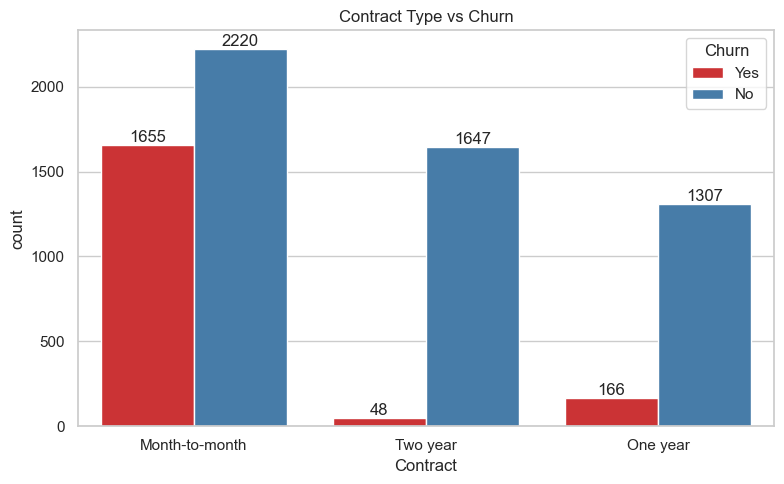

In [20]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Contract', hue='Churn', data=df, palette='Set1')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Contract Type vs Churn')
plt.tight_layout(); plt.show()

3. Internet Service vs Churn

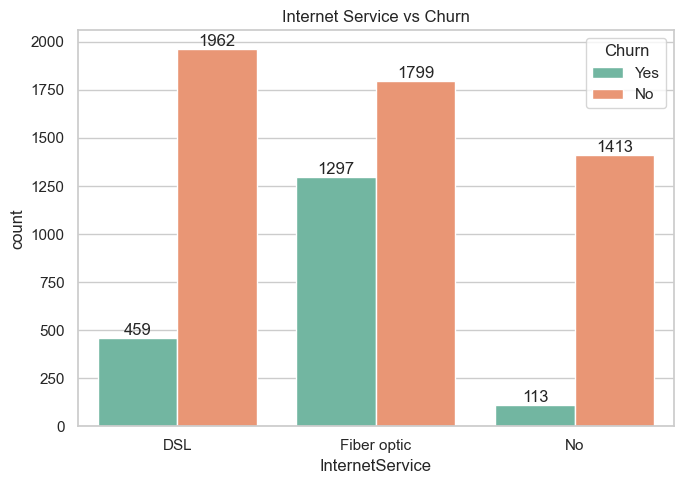

In [21]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='InternetService', hue='Churn', data=df, palette='Set2')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Internet Service vs Churn')
plt.tight_layout(); plt.show()

4. Payment Method vs Churn

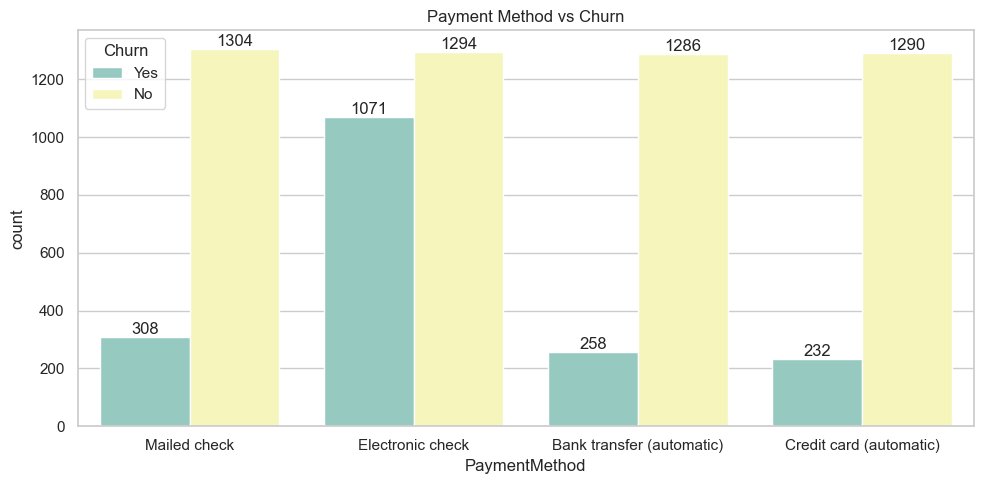

In [22]:
plt.figure(figsize=(10, 5))
ax = sns.countplot(x='PaymentMethod', hue='Churn', data=df, palette='Set3')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Payment Method vs Churn')
plt.tight_layout(); plt.show()

5. Monthly Charges vs Churn

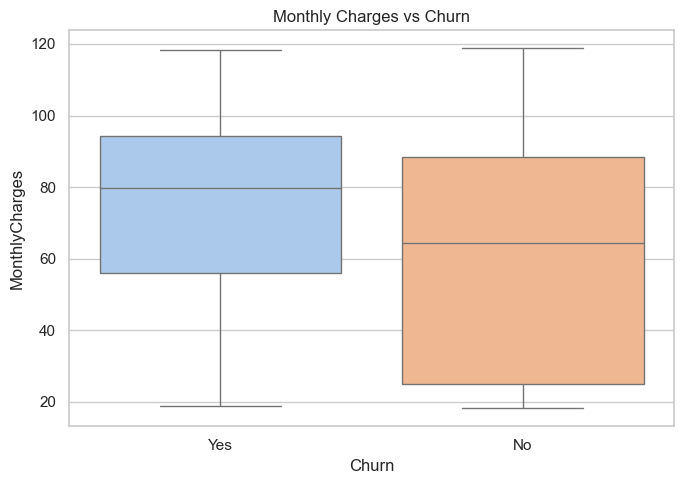

In [23]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='pastel')
plt.title('Monthly Charges vs Churn')
plt.tight_layout(); plt.show()

6. Tenure vs Churn

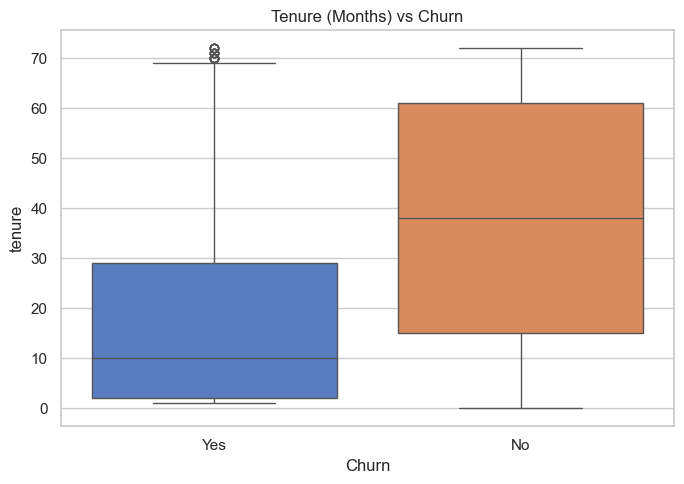

In [24]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='Churn', y='tenure', data=df, palette='muted')
plt.title('Tenure (Months) vs Churn')
plt.tight_layout(); plt.show()

7. Gender vs Churn

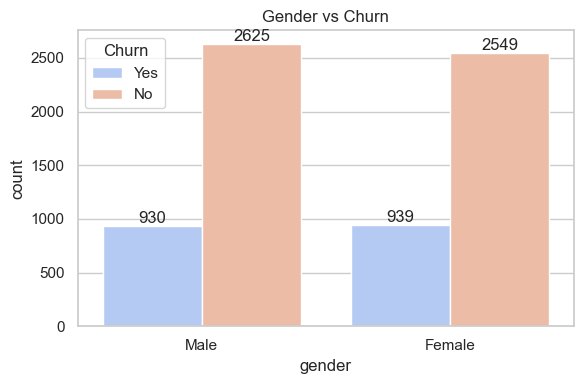

In [25]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='gender', hue='Churn', data=df, palette='coolwarm')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Gender vs Churn')
plt.tight_layout(); plt.show()

8. Correlation Heatmap (numeric features only)

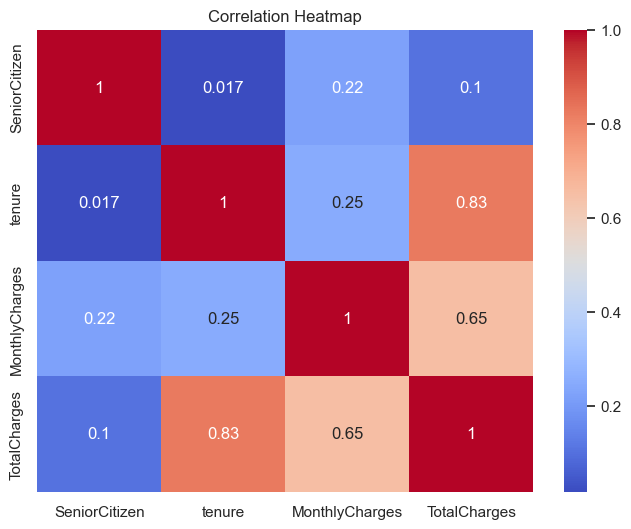

In [26]:
plt.figure(figsize=(8, 6))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Feature Engineering

In [27]:
# Feature 1: Tenure Group — bucket continuous tenure into life-stage segments
df['TenureGroup'] = np.where(df['tenure'] <= 12, 1,       # New (0-12 months)
                    np.where(df['tenure'] <= 24, 2,       # Growing (13-24 months)
                    np.where(df['tenure'] <= 48, 3, 4)))  # Established / Loyal

print('TenureGroup value counts:')
print(df['TenureGroup'].value_counts().sort_index())

NameError: name 'np' is not defined

In [ ]:
# Feature 2: Total Services — number of add-on services the customer subscribes to
# Higher engagement → lower churn risk
service_columns = [
    'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

df['TotalServices'] = 0
for col in service_columns:
    if col in df.columns:
        df['TotalServices'] += (df[col] == 'Yes').astype(int)

print('TotalServices summary:')
print(df['TotalServices'].describe())

In [ ]:
# Visualise: TotalServices vs Churn
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='TotalServices', data=df, palette='pastel')
plt.title('Total Add-on Services vs Churn')
plt.tight_layout(); plt.show()

## Encode Categorical Variables

In [ ]:
# Label-encode categorical columns

le = LabelEncoder()

categorical_cols = df.select_dtypes(include=["object", "string"]).columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

df.head()

In [ ]:
df.info()

## Prepare Features and Target

In [ ]:
# Features
X = df.drop("Churn", axis=1)

# Target
y = df["Churn"]

In [ ]:
# Train-Test Split: 80% train, 20% test 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Training samples: {X_train.shape[0]}')
print(f'Test samples    : {X_test.shape[0]}')

In [ ]:
# Feature Scaling — StandardScaler (zero mean, unit variance)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled  = scaler.transform(X_test)        

## Model 1: Logistic Regression

In [ ]:
# Train Logistic Regression on scaled data
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# Predict on test set
y_pred_lr = lr.predict(X_test_scaled)

# Compute all four key metrics
acc_lr  = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr  = recall_score(y_test, y_pred_lr)
f1_lr   = f1_score(y_test, y_pred_lr)

print('Logistic Regression Results:')
print(f'Accuracy : {acc_lr:.4f}')
print(f'Precision: {prec_lr:.4f}')
print(f'Recall   : {rec_lr:.4f}')
print(f'F1-Score : {f1_lr:.4f}')

In [ ]:
# Confusion Matrix — Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix — Logistic Regression')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()

In [ ]:
# Detailed Classification Report
print(classification_report(y_test, y_pred_lr, target_names=['No Churn', 'Churn']))

## Model 2: Random Forest Classifier

In [ ]:
# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)  # Tree models do not require feature scaling

# Predict on test set
y_pred_rf = rf.predict(X_test)

# Compute all four key metrics
acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf  = recall_score(y_test, y_pred_rf)
f1_rf   = f1_score(y_test, y_pred_rf)

print('Random Forest Results:')
print(f'Accuracy : {acc_rf:.4f}')
print(f'Precision: {prec_rf:.4f}')
print(f'Recall   : {rec_rf:.4f}')
print(f'F1-Score : {f1_rf:.4f}')

In [ ]:
# Confusion Matrix — Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix — Random Forest')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()

In [ ]:
# Detailed Classification Report
print(classification_report(y_test, y_pred_rf, target_names=['No Churn', 'Churn']))

## Model Comparison

In [ ]:
# Side-by-side comparison table — all values computed from actual model outputs
comparison = pd.DataFrame({
    'Model'    : ['Logistic Regression', 'Random Forest'],
    'Accuracy' : [round(acc_lr, 4),  round(acc_rf, 4)],
    'Precision': [round(prec_lr, 4), round(prec_rf, 4)],
    'Recall'   : [round(rec_lr, 4),  round(rec_rf, 4)],
    'F1-Score' : [round(f1_lr, 4),   round(f1_rf, 4)]
})

comparison.set_index('Model', inplace=True)
comparison

In [ ]:
# Visual comparison — grouped bar chart
comp_melted = comparison.reset_index().melt(
    id_vars='Model', var_name='Metric', value_name='Score'
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=comp_melted, x='Metric', y='Score',
                 hue='Model', palette='Set2')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.title('Model Comparison — Accuracy, Precision, Recall, F1-Score')
plt.ylim(0, 1.05)
plt.ylabel('Score')
plt.legend(title='Model')
plt.tight_layout(); plt.show()


## ROC-AUC Score for both models

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

# ROC-AUC Scores
auc_lr = roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1])
auc_rf = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])

print(f"Logistic Regression ROC-AUC : {auc_lr:.4f}")
print(f"Random Forest      ROC-AUC : {auc_rf:.4f}")

In [ ]:
# ROC Curve — both models on one chart
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr.predict_proba(X_test_scaled)[:, 1])
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf.predict_proba(X_test)[:, 1])

plt.figure(figsize=(8, 5))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})', color='steelblue')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})', color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Model Comparison')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Feature Importance — Random Forest
feature_names = X_train.columns  # adjust if you used a different variable name
importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values[:15], y=importances.index[:15], palette='viridis')
plt.title('Top 15 Feature Importances — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Business Insights & Recommendations

### Key Findings from EDA

|  | Insight | Business Impact |
|---|---------|----------------|
| 1 | **Month-to-month contracts** have the highest churn rate | Very High |
| 2 | **Fiber Optic** internet users churn more — likely price-sensitive | High |
| 3 | **Electronic check** payers churn at a higher rate | High |
| 4 | **Short-tenure customers (< 12 months)** are the most at-risk segment | High |
| 5 | Customers with **higher monthly charges** are more likely to churn | Medium |
| 6 | Customers with **more add-on services** churn less (higher engagement) | Medium |



### Actionable Recommendations

|  | Recommendation | Target Segment |
|---|----------------|----------------|
| 1 | Offer a **loyalty discount** to convert month-to-month customers to annual contracts within their first 3 months | New short-tenure customers |
| 2 | Introduce a **Fiber Optic value bundle** combining security + backup to justify the premium price | Fiber optic users without add-ons |
| 3 | Trigger an **automated retention outreach** (call/email) when a customer's churn probability score exceeds 0.6 | High-risk segment identified by model |
| 4 | Promote **auto-pay enrollment** (bank transfer/credit card) with a small monthly discount to reduce electronic check dependency | Electronic check payers |
| 5 | Create an **early engagement program** (onboarding, tutorials, add-on trials) for customers in their first 12 months | Tenure < 12 months |

## Power BI Dashboard

![Dashboard](dashboard.png)